Package install

In [1]:
%pip install scikit-learn xgboost lightgbm seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


Library Import

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor



Data Preview

In [3]:
df = pd.read_csv("quebec_housing_sales_cleaned.csv")

print(df.info())
print(df.describe())
print(df.head())


<class 'pandas.DataFrame'>
RangeIndex: 3789 entries, 0 to 3788
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              3789 non-null   str    
 1   neighborhood      3789 non-null   str    
 2   property_type     3789 non-null   str    
 3   bedrooms          3789 non-null   int64  
 4   bathrooms         3789 non-null   int64  
 5   living_area_sqft  3789 non-null   int64  
 6   lot_size_sqft     3789 non-null   float64
 7   year_built        3789 non-null   int64  
 8   garage            3789 non-null   str    
 9   basement          3789 non-null   str    
 10  sale_year         3789 non-null   int64  
 11  sale_price        3789 non-null   int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 355.3 KB
None
          bedrooms    bathrooms  living_area_sqft  lot_size_sqft   year_built  \
count  3789.000000  3789.000000       3789.000000    3789.000000  3789.000000   
mean      3.966218 

Encode Category DaTA

In [4]:
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

df.fillna(0, inplace=True)
df.describe()

C:\Users\sragu\AppData\Local\Temp\ipykernel_9084\181293259.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


,city,neighborhood,property_type,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,garage,basement,sale_year,sale_price
count,3789.000000,3789.000000,3789.000000,3789.000000,3789.000000,3789.000000,3789.000000,3789.000000,3789.000000,3789.000000,3789.000000,3.789000e+03
mean,15.189232,34.111903,2.101874,3.966218,2.589865,1493.411454,6257.154658,1982.889153,0.741093,0.800211,2023.401953,5.164566e+05
std,7.220456,21.598260,0.840293,1.179022,0.932043,395.156657,2811.434500,26.610985,0.438092,0.399894,1.335964,1.812421e+05
min,0.000000,0.000000,0.000000,2.000000,1.000000,746.000000,1570.000000,1900.000000,0.000000,0.000000,2021.000000,1.260000e+05
25%,11.000000,11.000000,2.000000,3.000000,2.000000,1169.000000,4086.000000,1965.000000,0.000000,1.000000,2022.000000,3.870000e+05
50%,15.000000,32.000000,2.000000,4.000000,3.000000,1478.000000,5767.000000,1984.000000,1.000000,1.000000,2024.000000,4.940000e+05
75%,18.000000,53.000000,2.000000,5.000000,3.000000,1749.000000,8005.000000,2005.000000,1.000000,1.000000,2025.000000,6.230000e+05
max,31.000000,71.000000,4.000000,8.000000,6.000000,2967.000000,14834.000000,2023.000000,1.000000,1.000000,2025.000000,1.425000e+06


Split

In [5]:
X = df.drop(columns=['sale_price'])
y = df['sale_price']

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
])

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42))
])

# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predictions
rf_pred = cross_val_predict(rf_pipeline, X, y, cv=kf)
xgb_pred = cross_val_predict(xgb_pipeline, X, y, cv=kf)

# Metrics
rf_rmse = np.sqrt(mean_squared_error(y, rf_pred))
rf_r2   = r2_score(y, rf_pred)

xgb_rmse = np.sqrt(mean_squared_error(y, xgb_pred))
xgb_r2   = r2_score(y, xgb_pred)

print("Random Forest -> RMSE:", rf_rmse, "R²:", rf_r2)
print("XGBoost       -> RMSE:", xgb_rmse, "R²:", xgb_r2)



Random Forest -> RMSE: 85495.18936438333 R²: 0.7774232787286478
XGBoost       -> RMSE: 69875.20395676853 R²: 0.8513234257698059


Comparisison of models

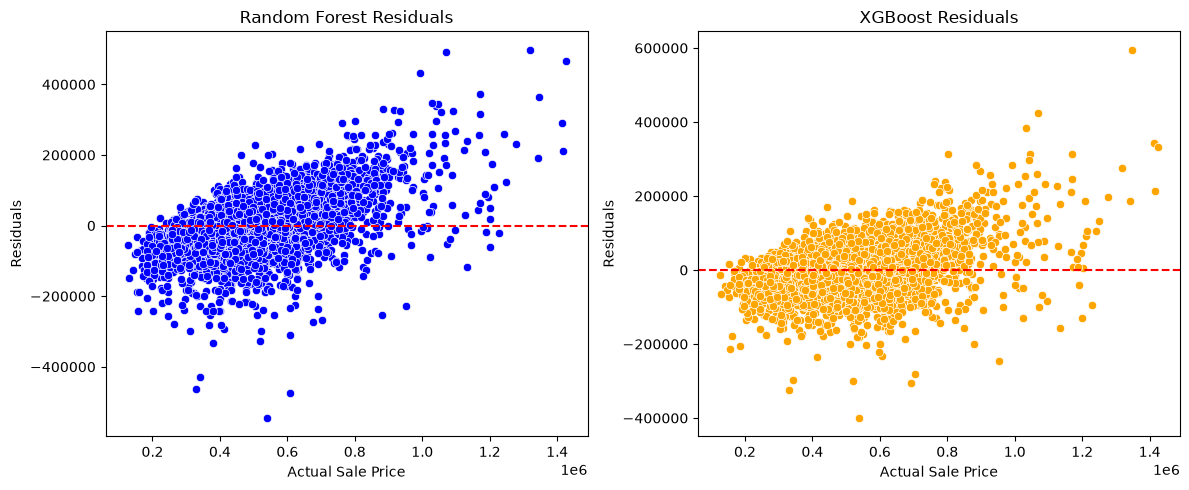

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=y, y=y-rf_pred, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title("Random Forest Residuals")
plt.xlabel("Actual Sale Price")
plt.ylabel("Residuals")

plt.subplot(1,2,2)
sns.scatterplot(x=y, y=y-xgb_pred, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.title("XGBoost Residuals")
plt.xlabel("Actual Sale Price")
plt.ylabel("Residuals")

plt.tight_layout()
plt.savefig("residuals_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


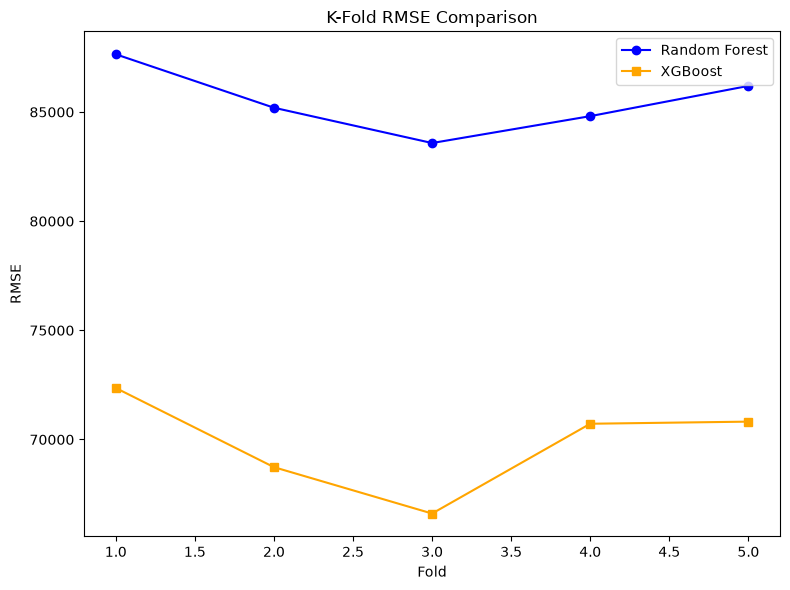

In [7]:
rf_scores = cross_val_score(rf_pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')
xgb_scores = cross_val_score(xgb_pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')

rf_rmse = np.sqrt(-rf_scores)
xgb_rmse = np.sqrt(-xgb_scores)

plt.figure(figsize=(8,6))
plt.plot(range(1, len(rf_rmse)+1), rf_rmse, marker='o', label='Random Forest', color='blue')
plt.plot(range(1, len(xgb_rmse)+1), xgb_rmse, marker='s', label='XGBoost', color='orange')

plt.title("K-Fold RMSE Comparison")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig("kfold_lineplot.png", dpi=300, bbox_inches='tight')
plt.show()


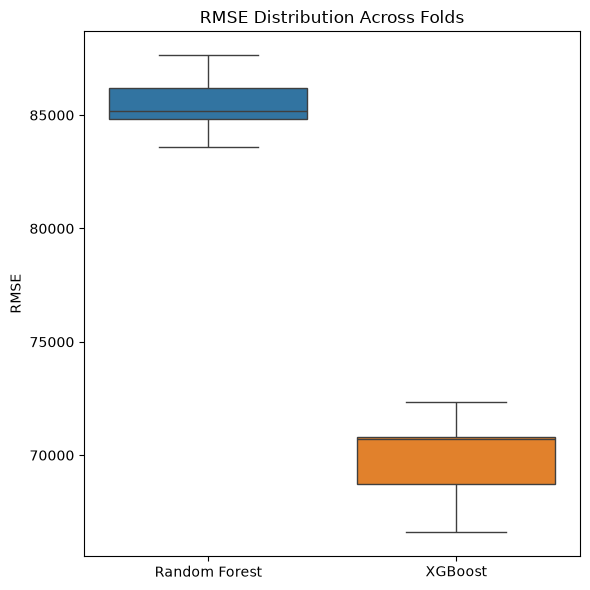

In [8]:
plt.figure(figsize=(6,6))
sns.boxplot(data=[rf_rmse, xgb_rmse])
plt.xticks([0,1], ['Random Forest','XGBoost'])
plt.title("RMSE Distribution Across Folds")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig("kfold_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


Prediction Function

In [9]:
def predict_price(input_dict, rf_model, xgb_model):

    new_input = pd.DataFrame([input_dict])

    rf_price = rf_model.predict(new_input)[0]
    xgb_price = xgb_model.predict(new_input)[0]

    return {
        "Random Forest Prediction": rf_price,
        "XGBoost Prediction": xgb_price
    }


Checking Accuracy

In [10]:

rf_pipeline.fit(X, y)
xgb_pipeline.fit(X, y)

new_house = {
    'city': 6,
    'neighborhood': 11,
    'property_type': 3,
    'bedrooms': 3,
    'bathrooms': 2,
    'living_area_sqft': 1160,
    'lot_size_sqft': 2304,
    'year_built': 2022,
    'garage': 1,
    'basement': 0,
    'sale_year': 2024,
}
predictions = predict_price(new_house, rf_pipeline, xgb_pipeline)
print(predictions)


{'Random Forest Prediction': np.float64(324633.88960005733), 'XGBoost Prediction': np.float32(299429.8)}
